# Crear los rezagos para cada variable seleccionada

--- Primeros registros del Dataset Original ---
       fecha   año  semana_epi  casos_ln   prec_ln  dias_lluvia_ln   temp_bc  \
0 2021-01-03  2021           1 -2.254057 -0.716557       -1.287582  0.777755   
1 2021-01-10  2021           2 -2.254057 -0.008387        0.420558  0.979193   
2 2021-01-17  2021           3 -1.667348 -2.051022       -2.365299  1.375442   
3 2021-01-24  2021           4 -2.254057 -0.328950        0.420558  1.238552   
4 2021-01-31  2021           5 -2.254057 -0.056645       -0.209866  1.324791   

   temp_max_bc  temp_min_bc  hum_esp_bc  hum_rel_bc  vel_vi_bc  vel_vi_max_bc  \
0     1.147942    -0.698761   -1.459162   -1.286497  -1.110633      -0.752514   
1     1.292774    -0.252083   -0.986872   -1.155330  -1.864950      -1.741631   
2     1.535146    -0.381025   -1.566311   -1.524280  -1.190152      -1.369313   
3     1.476318    -0.246876   -1.368638   -1.409824  -1.190152      -1.482924   
4     1.461364     0.331489   -0.990763   -1.335959  -1.518601    

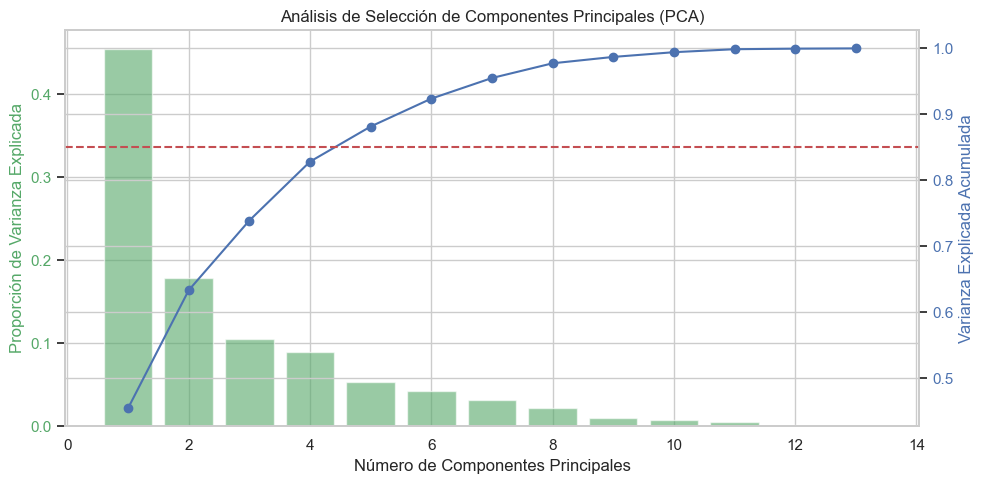


--- RESULTADOS DEL ANÁLISIS ---
Varianza explicada por cada componente: [4.54522571e-01 1.78821998e-01 1.05721756e-01 8.92440849e-02
 5.32379354e-02 4.22941770e-02 3.12529468e-02 2.23155860e-02
 9.65980085e-03 7.17854446e-03 4.51748645e-03 8.51058484e-04
 3.82054787e-04]
Varianza acumulada: [0.45452257 0.63334457 0.73906632 0.82831041 0.88154835 0.92384252
 0.95509547 0.97741105 0.98707086 0.9942494  0.99876689 0.99961795
 1.        ]
-> Número óptimo de componentes para explicar el 85% de la varianza: 5

--- MATRIZ DE CARGAS (LOADINGS) ---
Indica la correlación de las variables meteorológicas con cada PC:
                    PC_1      PC_2      PC_3      PC_4      PC_5
prec_ln         0.299415  0.159838  0.457704  0.123557 -0.087035
dias_lluvia_ln  0.305225  0.158081  0.435925  0.081321 -0.059609
temp_bc        -0.369435  0.204234 -0.072084  0.100173 -0.032607
temp_max_bc    -0.389659  0.036253 -0.052431  0.031400 -0.007356
temp_min_bc    -0.194945  0.489405  0.005140  0.195014 -0.14

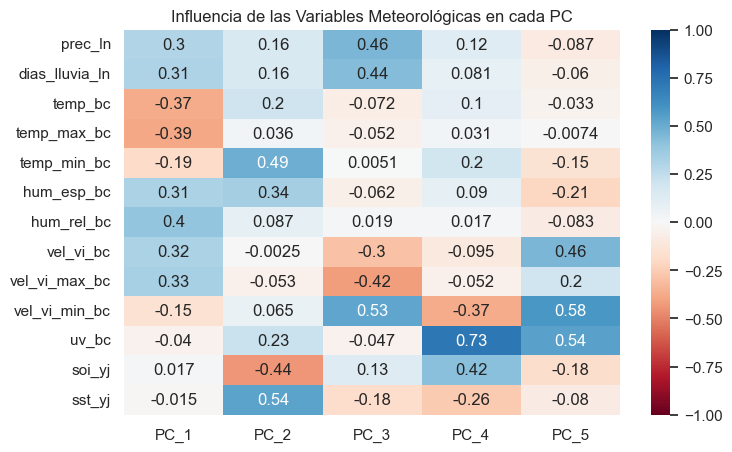


--- DATASET REDUCIDO CON VARIABLES DE CONTROL REINTEGRADAS ---
Listo para ingresar al modelo ARIMA (Exógenas + Target):
             año  semana_epi  casos_ln      PC_1      PC_2      PC_3  \
fecha                                                                  
2021-01-03  2021           1 -2.254057 -2.884217 -2.461538  0.693835   
2021-01-10  2021           2 -2.254057 -2.656038 -1.509957  2.015193   
2021-01-17  2021           3 -1.667348 -4.443311 -1.823922 -0.427094   
2021-01-24  2021           4 -2.254057 -2.860153 -1.052423  1.263168   
2021-01-31  2021           5 -2.254057 -2.943425 -0.710434  0.900078   

                PC_4      PC_5  
fecha                           
2021-01-03  0.670372  0.567945  
2021-01-10  1.416790 -0.552554  
2021-01-17  0.783827  1.106893  
2021-01-24  1.821709  0.332686  
2021-01-31  1.362148 -0.543904  


In [8]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuración estética de las gráficas
sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 2: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx"
df = pd.read_excel(ruta_datos)

print("--- Primeros registros del Dataset Original ---")
print(df.head())

# =============================================================================
# PASO 3: EXCLUSIÓN DE VARIABLES CONTROL/OBJETIVO Y ESCALADO (MEJORADO)
# =============================================================================
X = df.copy() 

# 1. Tratar el índice temporal si existe alguna columna de tipo fecha
columnas_fecha = X.select_dtypes(include=['datetime', 'datetime64']).columns.tolist()
if len(columnas_fecha) == 0:
    nombres_comunes = ['fecha', 'Fecha', 'date', 'Date', 'datetime', 'DateTime', 'tiempo', 'Tiempo']
    columnas_fecha = [col for col in nombres_comunes if col in X.columns]

if len(columnas_fecha) > 0:
    col_temporal = columnas_fecha[0]
    X[col_temporal] = pd.to_datetime(X[col_temporal])
    X.set_index(col_temporal, inplace=True)

# 2. MEJORA: Definir variables a excluir del PCA (no son meteorológicas)
# El script tolera mayúsculas/minúsculas para evitar errores por tipeo
columnas_a_excluir = ['año', 'semana_epi', 'casos_ln', 'ano', 'Semana_epi', 'Casos_ln', 'Año', 'SEMANA_EPI']
excluidas_presentes = [col for col in columnas_a_excluir if col in X.columns]

# Guardamos una copia de estas variables para reincorporarlas al final
df_variables_reservadas = X[excluidas_presentes].copy()

# Nos quedamos únicamente con las variables numéricas puramente meteorológicas
variables_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
variables_meteorologicas = [col for col in variables_numericas if col not in excluidas_presentes]

print(f"\n[INFO] Variables reservadas (quedan fuera del PCA): {excluidas_presentes}")
print(f"[INFO] Variables meteorológicas que entrarán al PCA: {variables_meteorologicas}")

X_meteo = X[variables_meteorologicas]

# 3. Escalado exclusivo de atributos meteorológicos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_meteo)

# =============================================================================
# PASO 4: AJUSTE INICIAL DE PCA (Evaluación de Componentes)
# =============================================================================
pca_completo = PCA()
pca_completo.fit(X_scaled)

# Cálculo de varianza explicada
varianza_explicada = pca_completo.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Visualización del Criterio de Selección
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, color='g', label='Varianza Individual')
ax1.set_xlabel('Número de Componentes Principales')
ax1.set_ylabel('Proporción de Varianza Explicada', color='g')
ax1.tick_params(axis='y', labelcolor='g')

ax2 = ax1.twinx()
ax2.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='b', label='Varianza Acumulada')
ax2.set_ylabel('Varianza Explicada Acumulada', color='b')
ax2.tick_params(axis='y', labelcolor='b')

umbral_varianza = 0.85
ax2.axhline(y=umbral_varianza, color='r', linestyle='--', label=f'Umbral ({int(umbral_varianza*100)}%)')

plt.title('Análisis de Selección de Componentes Principales (PCA)')
fig.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\criterio_seleccion_pca.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 5: DETERMINACIÓN DE LOS MEJORES COMPONENTES
# =============================================================================
n_componentes_optimo = np.argmax(varianza_acumulada >= umbral_varianza) + 1

print(f"\n--- RESULTADOS DEL ANÁLISIS ---")
print(f"Varianza explicada por cada componente: {varianza_explicada}")
print(f"Varianza acumulada: {varianza_acumulada}")
print(f"-> Número óptimo de componentes para explicar el {int(umbral_varianza*100)}% de la varianza: {n_componentes_optimo}")

# =============================================================================
# PASO 6: REDUCCIÓN Y REINTEGRACIÓN DEL DATASET FINAL (MEJORADO)
# =============================================================================
pca_final = PCA(n_components=n_componentes_optimo)
X_pca = pca_final.fit_transform(X_scaled)

# Crear DataFrame con los componentes resultantes
columnas_pca = [f'PC_{i}' for i in range(1, n_componentes_optimo + 1)]
df_pca = pd.DataFrame(data=X_pca, columns=columnas_pca, index=X_meteo.index)

# MEJORA: Concatenar las variables reservadas con los nuevos componentes climáticos
df_resultado = pd.concat([df_variables_reservadas, df_pca], axis=1)

# Examen de Cargas (Loadings) sobre el espacio meteorológico original
cargas = pd.DataFrame(
    pca_final.components_.T, 
    columns=columnas_pca, 
    index=X_meteo.columns
)

print("\n--- MATRIZ DE CARGAS (LOADINGS) ---")
print("Indica la correlación de las variables meteorológicas con cada PC:")
print(cargas)

# Visualización de las cargas en un mapa de calor
plt.figure(figsize=(8, 5))
sns.heatmap(cargas, annot=True, cmap='RdBu', vmin=-1, vmax=1)
plt.title('Influencia de las Variables Meteorológicas en cada PC')
plt.savefig(r"C:\Users\marco\Downloads\cargas_pca.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n--- DATASET REDUCIDO CON VARIABLES DE CONTROL REINTEGRADAS ---")
print("Listo para ingresar al modelo ARIMA (Exógenas + Target):")
print(df_resultado.head())

In [9]:
import os

# 1. Definir la nueva carpeta de destino
carpeta_destino = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\2_precesados"

# 2. Construir el nuevo nombre del archivo combinando el original con el sufijo requerido
nombre_original = os.path.basename(ruta_datos) # Extrae "1_datos_meteo_epi_sin_rezagos_escalados.xlsx"
nombre_base, extension = os.path.splitext(nombre_original) # Separa el nombre de la extensión
nuevo_nombre = f"{nombre_base}_con_pca_a_solo_cinco_dimensiones{extension}"

# 3. Guardar el archivo en la nueva ruta completa
ruta_salida_final = os.path.join(carpeta_destino, nuevo_nombre)
df_resultado.to_excel(ruta_salida_final)

print(f"\n[ÉXITO] Archivo exportado correctamente en:\n{ruta_salida_final}")


[ÉXITO] Archivo exportado correctamente en:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\2_precesados\1_datos_meteo_epi_sin_rezagos_escalados_con_pca_a_solo_cinco_dimensiones.xlsx
